In [1]:
import os
os.getcwd()


'C:\\Users\\VICTUS'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("customer_behavior_analysis.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [4]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 37.0 MB


In [6]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [7]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [8]:
df.median(numeric_only=True)

Customer ID              25011.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2725.0
Customer Age                44.0
Returns                      1.0
Age                         44.0
Churn                        0.0
dtype: float64

In [9]:
df.mode().iloc[0]

Customer ID                          48382.0
Purchase Date            2020-01-01 15:49:02
Product Category                 Electronics
Product Price                          290.0
Quantity                                 4.0
Total Purchase Amount                 2533.0
Payment Method                   Credit Card
Customer Age                            47.0
Returns                                  1.0
Customer Name                Michael Johnson
Age                                     47.0
Gender                                  Male
Churn                                    0.0
Name: 0, dtype: object

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [14]:
df.columns


Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')

In [15]:
df['Total_Spending'] = df['Quantity'] * df['Product Price']

In [16]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase Date'])

In [23]:
import pandas as pd
import datetime as dt

# Convert Purchase Date column to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Current date
today = dt.datetime.now()

# Create RFM table
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (today - x.max()).days,
    'Payment Method': 'count',
    'Total_Spending': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display output
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,1871,1,2280
2,1055,6,6459
3,1205,1,564
4,1424,5,4339
5,1520,3,1230


In [24]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,1871,1,2280,3
2,1055,6,6459,1
3,1205,1,564,2
4,1424,5,4339,0
5,1520,3,1230,3


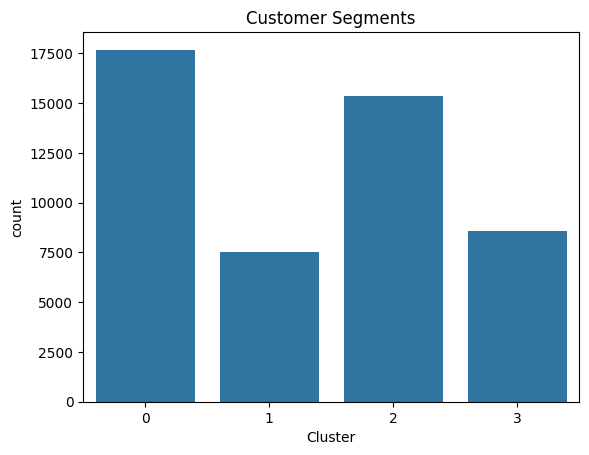

In [26]:
sns.countplot(x='Cluster', data=rfm)

plt.title("Customer Segments")
plt.show()

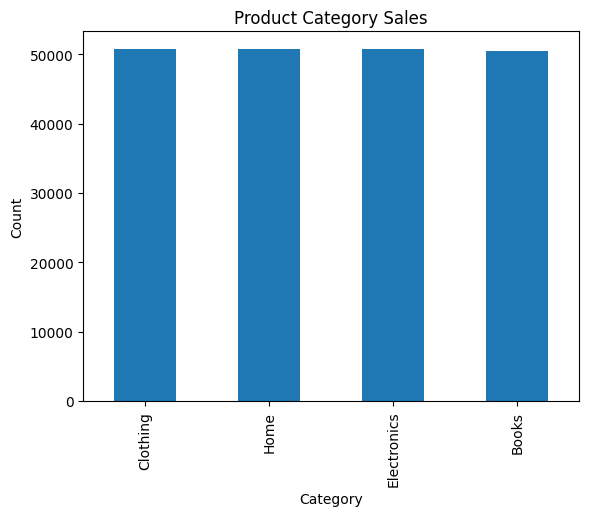

In [28]:
df['Product Category'].value_counts().plot(kind='bar')

plt.title("Product Category Sales")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

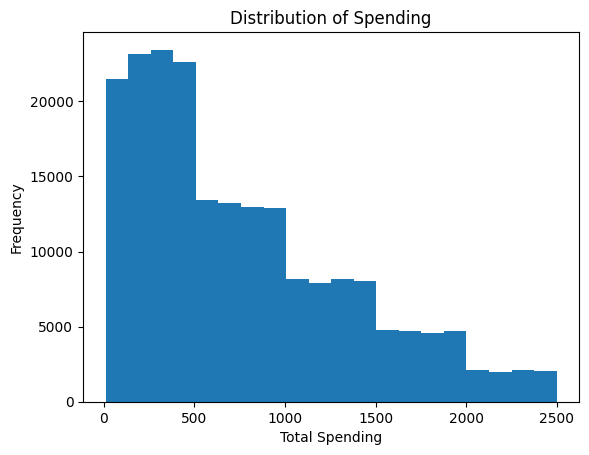

In [29]:
plt.hist(df['Total_Spending'], bins=20)

plt.title("Distribution of Spending")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")

plt.show()

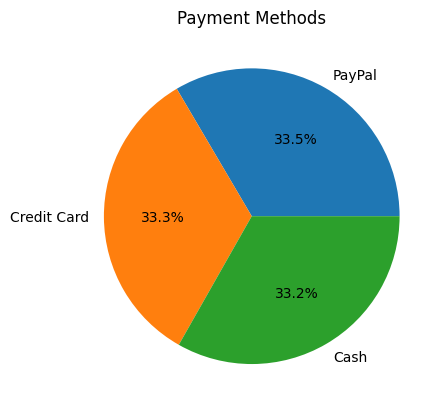

In [30]:
df['Payment Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Methods")

plt.show()

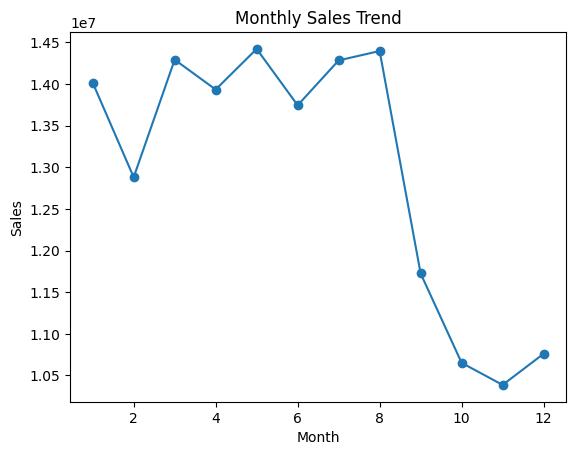

In [31]:
df['Month'] = df['Purchase Date'].dt.month

monthly_sales = df.groupby('Month')['Total_Spending'].sum()

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

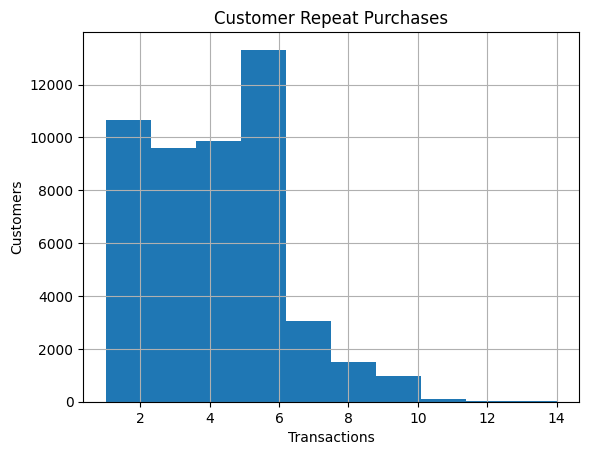

In [32]:
repeat_customers = df.groupby('Customer ID').size()

repeat_customers.hist()

plt.title("Customer Repeat Purchases")
plt.xlabel("Transactions")
plt.ylabel("Customers")

plt.show()

In [33]:
#Load Dataset in Jupyter

import pandas as pd

df = pd.read_csv("customer_behavior_analysis.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [34]:
#Check Dataset Information
df.dtypes

Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

In [35]:
#Missing Values
df.isnull().sum()


Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [36]:
#Summary StatisticsMean
df.describe()Mean


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [37]:
#Mean
df.mean(numeric_only=True)

Customer ID              25017.632092
Product Price              254.742724
Quantity                     3.004936
Total Purchase Amount     2725.385196
Customer Age                43.798276
Returns                      0.500824
Age                         43.798276
Churn                        0.200520
dtype: float64

In [38]:
#Median
df.median(numeric_only=True)

Customer ID              25011.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2725.0
Customer Age                44.0
Returns                      1.0
Age                         44.0
Churn                        0.0
dtype: float64

In [39]:
#mode
df.mode().iloc[0]

Customer ID                          48382.0
Purchase Date            2020-01-01 15:49:02
Product Category                 Electronics
Product Price                          290.0
Quantity                                 4.0
Total Purchase Amount                 2533.0
Payment Method                   Credit Card
Customer Age                            47.0
Returns                                  1.0
Customer Name                Michael Johnson
Age                                     47.0
Gender                                  Male
Churn                                    0.0
Name: 0, dtype: object

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns